# Código da Solução: Indústria Siderúrgica

## Steelproof

Etapa 2 do Projeto Final. Bootcamp de Data Science, TripleTen.

Este notebook executa o processo que descrevi no Plano de Trabalho da Etapa 1. A estrutura segue os
quatro blocos pedidos: processamento e limpeza, preparação para modelagem, modelamento e resumo dos
resultados.

O objetivo de negócio é prever a temperatura final do banho a partir da condição inicial e das
operações aplicadas, para dimensionar a carga de aquecimento em vez de buscá-la por tentativa e
erro. O KPI que defini no plano é MAE de no máximo 6,8 °C, contra um piso estimado de 12,8 °C do
modelo trivial.

Uma observação sobre a natureza do que construo aqui, que retomo na seção 4.3. Os arquivos trazem as
operações como foram executadas, não como foram planejadas. O modelo responde a uma pergunta
condicional, quanto o banho termina se determinado tratamento for aplicado, e é isso que permite
comparar planos de aquecimento antes de gastar a energia. Ele não é uma previsão passiva feita com o
lote parado na entrada.

Em vários pontos a execução sobre os dados reais divergiu do que eu havia previsto. Demonstro cada
desvio no ponto em que ele aparece e consolido todos na seção 4.4.

Uma convenção sobre o texto, que vale enunciar antes de começar. Não tenho acesso à operação, ao
histórico de manutenção nem à composição química das corridas. Tudo o que sei vem da estrutura dos
dados. Por isso separo o que é observado, que é o padrão nos registros, do que é assumido, que é a
causa que melhor explica esse padrão. Onde adoto uma causa sem poder verificá-la, digo isso com
essas palavras em vez de apresentá-la como fato estabelecido.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

# Os dados nao acompanham o repositorio: sao material do bootcamp e nao podem ser
# redistribuidos. Coloque os sete CSVs em data/raw/final_steel_en/ (ver README).
# Os demais candidatos preservam a execucao na plataforma e no layout antigo.
CANDIDATOS = [
    'data/raw/final_steel_en',
    '../data/raw/final_steel_en',
    'final_steel_en',
    './final_steel_en',
    '../final_steel_en',
    '/datasets/final_steel_en',
    '/datasets',
]
DADOS = next((p for p in CANDIDATOS if os.path.isdir(p) and
              os.path.isfile(os.path.join(p, 'data_arc_en.csv'))), None)
if DADOS is None:
    raise FileNotFoundError(
        'Os sete CSVs nao foram encontrados. Coloque-os em data/raw/final_steel_en/ '
        '(data_arc_en.csv, data_bulk_en.csv, data_bulk_time_en.csv, data_gas_en.csv, '
        'data_temp_en.csv, data_wire_en.csv, data_wire_time_en.csv). '
        f'Procurei em: {CANDIDATOS}'
    )
print('Dados em:', DADOS)


Dados em: final_steel_en


---

# 1. Processamento e limpeza de dados

## 1.1 Carga das sete fontes

O vínculo entre todas as tabelas é a coluna `key`, que identifica a corrida (lote). Duas fontes
têm múltiplas linhas por lote, porque registram a evolução temporal do tratamento: `data_arc_en`
(uma linha por ciclo de aquecimento) e `data_temp_en` (uma linha por medição de temperatura). As
demais têm exatamente uma linha por lote.

In [2]:
arc   = pd.read_csv(f'{DADOS}/data_arc_en.csv')
temp  = pd.read_csv(f'{DADOS}/data_temp_en.csv')
gas   = pd.read_csv(f'{DADOS}/data_gas_en.csv')
bulk  = pd.read_csv(f'{DADOS}/data_bulk_en.csv')
bulkt = pd.read_csv(f'{DADOS}/data_bulk_time_en.csv')
wire  = pd.read_csv(f'{DADOS}/data_wire_en.csv')
wiret = pd.read_csv(f'{DADOS}/data_wire_time_en.csv')

fontes = {'arc': arc, 'temp': temp, 'gas': gas, 'bulk': bulk,
          'bulk_time': bulkt, 'wire': wire, 'wire_time': wiret}

resumo = pd.DataFrame([
    {'fonte': nome, 'linhas': len(df), 'colunas': df.shape[1],
     'lotes': df['key'].nunique(), 'duplicadas': int(df.duplicated().sum())}
    for nome, df in fontes.items()
])
resumo

,fonte,linhas,colunas,lotes,duplicadas
0,arc,14876,5,3214,0
1,temp,15907,3,3216,0
2,gas,3239,2,3239,0
3,bulk,3129,16,3129,0
4,bulk_time,3129,16,3129,0
5,wire,3081,10,3081,0
6,wire_time,3081,10,3081,0


Nenhuma fonte tem linhas duplicadas. A contagem de lotes varia entre os arquivos (3.239 no gás,
3.216 na temperatura, 3.214 no arco, 3.129 no granel, 3.081 no arame), o que significa que o
cruzamento vai gerar ausências por falta de registro em determinadas fontes. A seção 1.5 trata
cada uma conforme sua natureza.

## 1.2 Ajuste de tipos

Os campos de data e hora chegam como texto e precisam virar `datetime`, sem o que não é possível
ordenar medições dentro do lote nem calcular durações. As demais colunas já chegam com o tipo
correto: `key` como inteiro e as grandezas físicas como ponto flutuante.

In [3]:
arc['Arc heating start'] = pd.to_datetime(arc['Arc heating start'])
arc['Arc heating end']   = pd.to_datetime(arc['Arc heating end'])
temp['Sampling time']    = pd.to_datetime(temp['Sampling time'])

print(arc.dtypes.to_string())
print()
print(temp.dtypes.to_string())

key                           int64
Arc heating start    datetime64[us]
Arc heating end      datetime64[us]
Active power                float64
Reactive power              float64

key                       int64
Sampling time    datetime64[us]
Temperature             float64


## 1.3 Inconsistência lógica em `Reactive power`

Observado: a potência reativa registra um mínimo de −715,5 contra uma mediana de 0,416 e um máximo
de 2,676. É um único registro, três ordens de grandeza fora da faixa em que todos os demais operam,
e com o sinal invertido.

Assumido: leitura inválida. Não tenho como distinguir falha de sensor, erro de transmissão ou falha
de gravação. Sei apenas que o valor não é compatível com a faixa de operação dos outros 14.875
registros.

Trato como ausente e não como zero, porque zero afirmaria que não houve potência reativa, quando o
que a análise sustenta é só que a medição não é utilizável.

In [4]:
print('Antes :', arc['Reactive power'].min(), '->', arc['Reactive power'].max())
invalidos = arc['Reactive power'] < 0
print(f'Leituras negativas: {invalidos.sum()} de {len(arc)}')

arc.loc[invalidos, 'Reactive power'] = np.nan
print('Depois:', arc['Reactive power'].min(), '->', arc['Reactive power'].max())

Antes : -715.5049241780999 -> 2.6763875484
Leituras negativas: 1 de 14876
Depois: 0.0208063126 -> 2.6763875484


## 1.4 Definição da variável-alvo e proteção contra vazamento

O alvo é a última temperatura medida de cada lote. A definição exige cuidado, porque a tabela de
temperaturas contém a própria resposta que quero prever. Usar qualquer medição intermediária como
atributo produziria um modelo com erro artificialmente baixo e inútil na prática, porque dependeria
de informação que só existe depois do consumo de energia.

A regra que apliquei é estrita: apenas a primeira medição do lote entra como atributo, e todas as
demais existem exclusivamente para construir o alvo.

Além disso, `Temperature` tem 18,2% de valores ausentes. Um lote só é aproveitável se tiver ao menos
duas medições válidas, porque a primeira serve de entrada e a última de alvo.

In [5]:
t = temp.dropna(subset=['Temperature']).sort_values(['key', 'Sampling time'])

n_medicoes = t.groupby('key').size()
print(f'Lotes com >= 1 medicao valida : {(n_medicoes >= 1).sum()}')
print(f'Lotes com >= 2 medicoes validas: {(n_medicoes >= 2).sum()}')

aproveitaveis = n_medicoes[n_medicoes >= 2].index
t2 = t[t['key'].isin(aproveitaveis)]

base = (t2.groupby('key')
          .agg(temp_final=('Temperature', 'last'),
               temp_inicial=('Temperature', 'first'),
               t_primeira=('Sampling time', 'first'),
               t_ultima=('Sampling time', 'last'),
               n_medicoes=('Temperature', 'size'))
          .reset_index())
print(f'\nBase de lotes aproveitaveis: {len(base)}')
base.head()

Lotes com >= 1 medicao valida : 3216
Lotes com >= 2 medicoes validas: 2475

Base de lotes aproveitaveis: 2475


,key,temp_final,temp_inicial,t_primeira,t_ultima,n_medicoes
0,1,1613.0,1571.0,2019-05-03 11:16:18,2019-05-03 11:30:39,5
1,2,1602.0,1581.0,2019-05-03 11:37:27,2019-05-03 11:59:12,6
2,3,1599.0,1596.0,2019-05-03 12:13:17,2019-05-03 12:34:57,5
3,4,1625.0,1601.0,2019-05-03 12:52:57,2019-05-03 12:59:25,3
4,5,1602.0,1576.0,2019-05-03 13:23:19,2019-05-03 13:36:01,2


## 1.5 A quebra de registro em 06/08/2019

Observado: até 05/08/2019 os lotes têm múltiplas medições de temperatura, e a partir de 06/08/2019
passam a ter uma única medição por lote. A transição acontece em uma data específica, não de forma
gradual, e os registros continuam existindo, sem lacuna nos arquivos.

Assumido: que houve mudança no protocolo de gravação do sistema da fábrica. Não tenho acesso à
operação para confirmar isso. O que a estrutura dos dados permite dizer é que o padrão é compatível
com uma mudança no que passou a ser registrado, e não com falha de sensor. Falha de sensor
produziria ausência de registro ou valores inválidos, não uma redução limpa e permanente na
quantidade de leituras a partir de uma data.

Qualquer que seja a causa, a consequência para este trabalho é a mesma. Com uma única leitura por
corrida fica impossível separar entrada e alvo, e o período precisa sair.

Aqui o plano foi impreciso em um ponto: os dois filtros se sobrepõem. O critério das duas medições
já elimina quase toda a janela de agosto por conta própria, e o corte explícito por data remove
apenas os poucos lotes sobreviventes.

In [6]:
CORTE = pd.Timestamp('2019-08-06')

antes = len(base)
base = base[base['t_primeira'] < CORTE].copy()
print(f'Corte em 06/08/2019: {antes} -> {len(base)} lotes (removidos {antes - len(base)})')
print(f'Periodo integro: {base["t_primeira"].min().date()} a {base["t_primeira"].max().date()}')

Corte em 06/08/2019: 2475 -> 2469 lotes (removidos 6)
Periodo integro: 2019-05-03 a 2019-08-05


## 1.6 Agregação dos eventos por lote

As fontes com múltiplas linhas por lote precisam ser reduzidas a uma linha, e a escolha de como
agregar é uma decisão de modelagem, não uma formalidade. Somo as potências ativa e reativa, porque
o que interessa é o esforço elétrico total da corrida. Conto os ciclos de aquecimento, que são a
variável operacional que o modelo deve ajudar a reduzir. Somo as durações das janelas de arco. E
calculo a energia como `Active power` vezes duração, convertida para hora, que é a grandeza
fisicamente ligada à elevação de temperatura e que uso na seção 1.8 para testar a premissa de massa.

Nas tabelas de granel e arame, assumo que célula em branco significa material não adicionado naquela
corrida, e não medição perdida. O que sustenta essa leitura é a estrutura dos arquivos. As tabelas
de massa e de instante de adição têm exatamente o mesmo padrão de ausência, célula a célula: quando
não há massa registrada, também não há horário de adição. Uma falha de medição de massa deixaria o
horário gravado.

Sob essa premissa o preenchimento correto é zero. Preencher com a média inventaria adições que nunca
aconteceram.

`Bulk 8` e `Wire 5` têm um único registro válido em todo o conjunto, mais de 99,9% de ausência, e
descarto as duas. Uma coluna com uma observação não sustenta aprendizado, seja qual for a causa da
ausência das demais.

In [7]:
arc['dur_min'] = (arc['Arc heating end'] - arc['Arc heating start']).dt.total_seconds() / 60
arc['energia_mwh'] = arc['Active power'] * arc['dur_min'] / 60

arc_ag = (arc.groupby('key')
             .agg(potencia_ativa_total=('Active power', 'sum'),
                  potencia_reativa_total=('Reactive power', 'sum'),
                  n_aquecimentos=('Active power', 'size'),
                  tempo_arco_min=('dur_min', 'sum'),
                  energia_mwh=('energia_mwh', 'sum'),
                  arc_inicio=('Arc heating start', 'min'),
                  arc_fim=('Arc heating end', 'max'))
             .reset_index())
arc_ag.head()

,key,potencia_ativa_total,potencia_reativa_total,n_aquecimentos,tempo_arco_min,energia_mwh,arc_inicio,arc_fim
0,1,4.878147,3.183241,5,18.300000,0.335501,2019-05-03 11:02:14,2019-05-03 11:28:37
1,2,3.052598,1.998112,4,13.516667,0.203838,2019-05-03 11:34:14,2019-05-03 11:53:18
2,3,2.525882,1.599076,5,10.916667,0.123218,2019-05-03 12:06:54,2019-05-03 12:32:19
3,4,3.209250,2.060298,4,12.350000,0.186295,2019-05-03 12:39:37,2019-05-03 12:57:50
4,5,3.347173,2.252643,4,14.483333,0.277082,2019-05-03 13:11:13,2019-05-03 13:33:55


In [8]:
# Teste da premissa: se a ausencia significa "material nao adicionado", entao a tabela de massa
# e a de horario devem estar em branco exatamente nas mesmas celulas. Uma falha de medicao de
# massa deixaria o horario gravado, e as duas divergiriam.
for nome, (massa, horario) in {'bulk': (bulk, bulkt), 'wire': (wire, wiret)}.items():
    assert (massa['key'] == horario['key']).all(), 'ordem das linhas difere'
    cols = [c for c in massa.columns if c != 'key']
    divergencias = (massa[cols].isna().values != horario[cols].isna().values).sum()
    print(f'{nome}: {massa[cols].size} celulas | divergencias massa-vs-horario: {divergencias}')

bulk: 46935 celulas | divergencias massa-vs-horario: 0
wire: 27729 celulas | divergencias massa-vs-horario: 0


In [9]:
bulk = bulk.drop(columns=['Bulk 8'])
wire = wire.drop(columns=['Wire 5'])

bulk_cols = [c for c in bulk.columns if c != 'key']
wire_cols = [c for c in wire.columns if c != 'key']

bulk[bulk_cols] = bulk[bulk_cols].fillna(0)
wire[wire_cols] = wire[wire_cols].fillna(0)

bulk['bulk_total']   = bulk[bulk_cols].sum(axis=1)
bulk['n_bulk_tipos'] = (bulk[bulk_cols] > 0).sum(axis=1)
wire['wire_total']   = wire[wire_cols].sum(axis=1)
wire['n_wire_tipos'] = (wire[wire_cols] > 0).sum(axis=1)

print(f'Granel: {len(bulk_cols)} colunas de material + 2 agregadas')
print(f'Arame : {len(wire_cols)} colunas de material + 2 agregadas')

Granel: 14 colunas de material + 2 agregadas
Arame : 8 colunas de material + 2 agregadas


## 1.7 Junção das fontes

A junção é feita à esquerda a partir da base de lotes aproveitáveis, que já carrega o alvo. Lotes
sem registro de arco não teriam a variável central do problema e seriam descartados; lotes sem
granel ou arame simplesmente não receberam aquele tipo de adição, e vão a zero.

In [10]:
df = (base
      .merge(arc_ag, on='key', how='left')
      .merge(gas,    on='key', how='left')
      .merge(bulk,   on='key', how='left')
      .merge(wire,   on='key', how='left'))

print(f'Apos a juncao: {len(df)} lotes, {df.shape[1]} colunas')
print('\nAusencias introduzidas pelo cruzamento:')
print(df[['potencia_ativa_total', 'Gas 1', 'bulk_total', 'wire_total']].isna().sum().to_string())

Apos a juncao: 2469 lotes, 40 colunas

Ausencias introduzidas pelo cruzamento:
potencia_ativa_total      0
Gas 1                     2
bulk_total               68
wire_total              103


In [11]:
# Sem registro de arco: nao ha como caracterizar o aquecimento do lote.
antes = len(df)
df = df.dropna(subset=['potencia_ativa_total'])
print(f'Sem registro de arco : {antes} -> {len(df)}')

# Sem registro de gas: sao poucos casos e preencher com zero afirmaria "nao houve purga",
# quando o mais provavel e falta de registro. Removo em vez de inventar o valor.
antes = len(df)
df = df.dropna(subset=['Gas 1'])
print(f'Sem registro de gas  : {antes} -> {len(df)}')

# Granel/arame ausentes: material nao adicionado -> zero.
for c in bulk_cols + wire_cols + ['bulk_total', 'wire_total', 'n_bulk_tipos', 'n_wire_tipos']:
    df[c] = df[c].fillna(0)

print(f'\nAusencias restantes: {int(df.isna().sum().sum())}')

Sem registro de arco : 2469 -> 2469
Sem registro de gas  : 2469 -> 2467

Ausencias restantes: 0


## 1.8 Duração do tratamento e leituras impossíveis

### Duração

A duração vai do primeiro aquecimento à última medição. No plano previ remover as duas caudas.
Tratamentos acima de 100,6 min, que é o percentil 99, não refletem o processo normal, porque o aço
troca calor com o refratário por tempo excessivo e a dinâmica térmica deixa de ser a mesma. Abaixo
de 1 min indicam operação abortada.

### As quatro leituras iniciais impossíveis

Quatro lotes registram temperatura inicial entre 1.191 e 1.227 °C, contra um percentil 1 de
1.532 °C, e todos terminam na faixa normal. No plano eu os tratava como um único outlier
estatístico.

Descartar por distância da média seria fraco. E o argumento metalúrgico óbvio, o de que aço não é
líquido a 1.200 °C, não se sustenta: o ponto de fusão depende da liga e eu não tenho a composição
química de nenhuma corrida.

O argumento que se sustenta é energético e interno aos dados. Meço na própria planta quanta energia
é necessária por grau de elevação e comparo com o que cada um desses quatro lotes de fato consumiu.

In [12]:
df['duracao_min'] = (df['t_ultima'] - df['arc_inicio']).dt.total_seconds() / 60
print(df['duracao_min'].describe(percentiles=[.01, .25, .5, .75, .99]).to_string())

antes = len(df)
df = df[(df['duracao_min'] >= 1) & (df['duracao_min'] <= 100.6)]
print(f'\nCorte de duracao (1 a 100,6 min): {antes} -> {len(df)} (removidos {antes - len(df)})')

count    2467.000000
mean       35.511607
std        21.706368
min         2.383333
1%         11.879667
25%        24.500000
50%        31.316667
75%        41.950000
99%        99.907333
max       395.066667

Corte de duracao (1 a 100,6 min): 2467 -> 2442 (removidos 25)


In [13]:
# Taxa energetica da planta, medida nos lotes que de fato aqueceram.
normais = df[(df['temp_final'] > df['temp_inicial']) & (df['temp_inicial'] > 1400)].copy()
normais['delta_t'] = normais['temp_final'] - normais['temp_inicial']
taxa = (normais['energia_mwh'] / normais['delta_t']).median()
print(f'Energia mediana por grau de elevacao: {taxa:.5f} MWh/C')

suspeitos = df[df['temp_inicial'] <= 1400].copy()
suspeitos['delta_t']    = suspeitos['temp_final'] - suspeitos['temp_inicial']
suspeitos['necessaria'] = suspeitos['delta_t'] * taxa
suspeitos['fracao_%']   = 100 * suspeitos['energia_mwh'] / suspeitos['necessaria']

print()
print(suspeitos[['key', 'temp_inicial', 'temp_final', 'delta_t',
                 'necessaria', 'energia_mwh', 'fracao_%', 'tempo_arco_min']]
      .round(3).to_string(index=False))

Energia mediana por grau de elevacao: 0.01213 MWh/C

 key  temp_inicial  temp_final  delta_t  necessaria  energia_mwh  fracao_%  tempo_arco_min
 867        1191.0      1599.0    408.0       4.948        0.186     3.766          16.150
1214        1208.0      1591.0    383.0       4.645        0.124     2.659           8.017
1619        1218.0      1590.0    372.0       4.512        0.029     0.653           4.100
2052        1227.0      1592.0    365.0       4.427        0.113     2.545          10.550


Observado: esses lotes registram elevação de 365 a 408 °C tendo consumido entre 0,6% e 3,7% da
energia que a própria planta gasta para essa elevação. Um deles registra alta de 372 °C com 4,1
minutos de arco ligado.

Assumido: que a leitura inválida é a primeira, e não a última. A escolha não é arbitrária, porque a
temperatura final desses quatro lotes cai na faixa normal de operação e a inicial é a que destoa.
Ainda assim é uma atribuição que os dados sozinhos não fecham. O que eles fecham é que as duas
leituras do mesmo lote são mutuamente incompatíveis dado o consumo registrado entre elas.

Para o tratamento a distinção é indiferente, porque o lote sai da amostra nas duas hipóteses. E a
conclusão não depende de nenhuma suposição sobre a liga ou o ponto de fusão, apenas da taxa
energética que medi na própria planta.

In [14]:
antes = len(df)
df = df[df['temp_inicial'] > 1400]
print(f'Remocao das leituras impossiveis: {antes} -> {len(df)}')

Remocao das leituras impossiveis: 2442 -> 2438


## 1.9 Intervalo desde o lote anterior

Esta é a única variável que construo a partir da ordenação temporal, e a hipótese física que a
justifica é simples: uma panela que acabou de processar uma corrida está mais quente e rouba menos
calor do banho seguinte. Sob essa hipótese, o intervalo desde o fim do lote anterior funciona como
proxy do estado térmico do refratário. E a hipótese é testável. Se ela valer, a variável terá
importância não desprezível no modelo, e volto a esse ponto na análise de importância da seção 3.8.

Vale distinguir esta variável de `key` e dos timestamps crus, que nunca entram como atributos.
Aqueles codificariam a posição na série, ou seja, permitiriam ao modelo decorar a ordem em vez de
aprender a física. O intervalo mede uma grandeza com significado térmico.

Sobre os intervalos negativos. Observo que em alguns lotes o aquecimento começa antes do fim
registrado do lote anterior. No plano da Etapa 1 assumi que se trata de corridas atípicas e
demoradas invadindo o tempo da panela seguinte, e não de duas estações operando em paralelo. O que
sustenta essa leitura é que esses casos têm duração mediana muito acima da geral. Não tenho como
verificar o leiaute da planta. No tratamento, limito os valores a zero e marco cada caso com uma
bandeira, o que permite ao modelo tratá-los à parte seja qual for a causa.

In [15]:
df = df.sort_values('key').reset_index(drop=True)

df['intervalo_min']   = (df['arc_inicio'] - df['t_ultima'].shift(1)).dt.total_seconds() / 60
df['lote_sobreposto'] = (df['intervalo_min'] < 0).astype(int)
df['intervalo_min']   = df['intervalo_min'].clip(lower=0)
df['intervalo_min']   = df['intervalo_min'].fillna(df['intervalo_min'].median())

print(f'Intervalo mediano entre lotes: {df["intervalo_min"].median():.1f} min')
print(f'Lotes sobrepostos ao anterior: {df["lote_sobreposto"].sum()}')
print(df['intervalo_min'].describe(percentiles=[.25, .5, .75, .99]).to_string())

Intervalo mediano entre lotes: 11.4 min
Lotes sobrepostos ao anterior: 63
count    2438.000000
mean       22.896876
std       146.820446
min         0.000000
25%         7.166667
50%        11.400000
75%        20.358333
99%       169.669667
max      7087.800000


## 1.10 Dataset consolidado

Resumo dos cortes aplicados, do total bruto ao conjunto final.

In [16]:
print(f'DATASET FINAL: {len(df)} lotes, {df.shape[1]} colunas')
print(f'Periodo: {df["arc_inicio"].min()} a {df["arc_inicio"].max()}')
print()
print('Variavel-alvo (temperatura final):')
print(df['temp_final'].describe().round(2).to_string())

DATASET FINAL: 2438 lotes, 43 colunas
Periodo: 2019-05-03 11:02:14 a 2019-08-05 23:31:07

Variavel-alvo (temperatura final):
count    2438.00
mean     1595.43
std        15.88
min      1550.00
25%      1587.00
50%      1593.00
75%      1599.00
max      1700.00


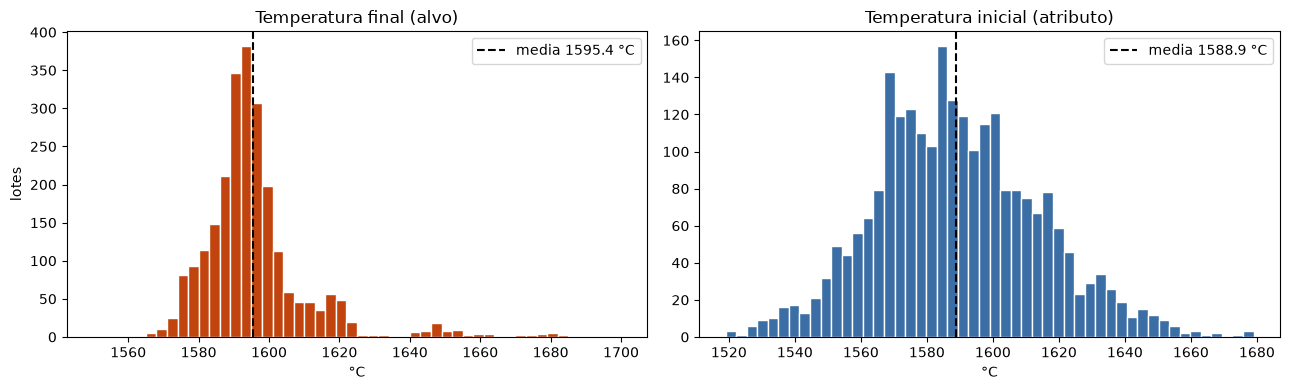

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].hist(df['temp_final'], bins=50, color='#c1440e', edgecolor='white')
ax[0].axvline(df['temp_final'].mean(), color='black', ls='--',
              label=f'media {df["temp_final"].mean():.1f} °C')
ax[0].set_title('Temperatura final (alvo)')
ax[0].set_xlabel('°C'); ax[0].set_ylabel('lotes'); ax[0].legend()

ax[1].hist(df['temp_inicial'], bins=50, color='#3b6ea5', edgecolor='white')
ax[1].axvline(df['temp_inicial'].mean(), color='black', ls='--',
              label=f'media {df["temp_inicial"].mean():.1f} °C')
ax[1].set_title('Temperatura inicial (atributo)')
ax[1].set_xlabel('°C'); ax[1].legend()

plt.tight_layout(); plt.show()

Observado: a temperatura final é muito menos dispersa que a inicial, com desvio de 15,9 °C contra
29,2 °C, cerca de metade.

Assumido: que isso reflete um processo de controle convergente, em que a operação recebe banhos em
condições variadas e os entrega em torno de um setpoint estreito. É a leitura mais natural do
padrão, mas não tenho o setpoint documentado nem o procedimento operacional para confirmá-la.

A consequência para a modelagem vale seja qual for a causa, e é o ponto mais importante desta seção.
Desvio padrão pequeno no alvo significa que há pouca variância a explicar. O KPI de 6,8 °C precisa
ser lido contra esse teto, sendo menos da metade do desvio padrão do próprio alvo, e não contra a
escala absoluta das temperaturas, que passa de 1.500 °C.

---

# 2. Preparação dos dados para o modelamento

## 2.1 Seleção de atributos e o que fica de fora

Nem toda coluna do dataset consolidado pode entrar no modelo. Excluo três grupos, cada um por um
motivo diferente.

O identificador e os timestamps (`key`, `arc_inicio`, `arc_fim`, `t_primeira`, `t_ultima`) saem
conforme o desenho experimental da Etapa 1. Eles codificariam a posição na série temporal em vez da
física do processo, e o modelo poderia decorar a ordem de produção. O único aspecto temporal que
entra é o intervalo desde o lote anterior, que mede uma grandeza com significado térmico.

O número de medições (`n_medicoes`) sai porque não é uma operação aplicada ao banho, e sim um
subproduto do procedimento de medição: só se sabe quantas leituras houve depois que a corrida
terminou. Isso basta para excluí-lo, sem precisar recorrer à interpretação plausível mas não
verificável de que muitas medições indicariam um lote difícil de convergir. Ele também não consta da
lista de preditores do plano.

A duração até a última medição (`duracao_min`) é o caso mais sutil, e vale explicitar porque parece
um atributo inocente. Essa duração termina no instante em que o alvo é medido, ou seja, depende de
quando a última leitura aconteceu. Usá-la é uma forma discreta de vazamento.

No lugar dela entra `duracao_arco_span_min`, medida do primeiro ao último aquecimento. Descreve a
mesma noção de quanto tempo o lote passou em tratamento, mas é definida só por eventos de arco, sem
referência ao momento da medição final.

In [18]:
# Os nomes vindos dos CSVs tem espacos ('Bulk 1', 'Gas 1', 'Wire 2'), que o LightGBM rejeita.
# Padronizo aqui, e nao na carga, para que as secoes de limpeza acima continuem legiveis
# com os nomes originais dos arquivos.
df = df.rename(columns=lambda c: c.strip().lower().replace(' ', '_'))
print('exemplos de nomes padronizados:', [c for c in df.columns if c.startswith(('bulk_', 'wire_', 'gas_'))][:6])

exemplos de nomes padronizados: ['gas_1', 'bulk_1', 'bulk_2', 'bulk_3', 'bulk_4', 'bulk_5']


In [19]:
df['duracao_arco_span_min'] = (df['arc_fim'] - df['arc_inicio']).dt.total_seconds() / 60

# O descanso da panela satura: a diferenca entre 10 e 60 min parados e grande, entre 4 e 5 dias
# e irrelevante (a panela ja esfriou por completo). O log reflete essa saturacao e impede que a
# parada programada de 4,9 dias domine sozinha o ajuste dos modelos lineares.
df['log_intervalo'] = np.log1p(df['intervalo_min'])

EXCLUIR = ['key', 'temp_final', 'arc_inicio', 'arc_fim', 't_primeira', 't_ultima',
           'n_medicoes', 'duracao_min', 'intervalo_min']

atributos = [c for c in df.columns if c not in EXCLUIR]
X = df[atributos].copy()
y = df['temp_final'].copy()

print(f'Atributos: {len(atributos)}')
print(f'Observacoes: {len(X)}')
print()
print('Tipos presentes em X:')
print(X.dtypes.value_counts().to_string())

Atributos: 36
Observacoes: 2438

Tipos presentes em X:
float64    34
int64       2


## 2.2 Codificação de atributos não numéricos

O enunciado pede codificação de variáveis não numéricas. Depois da preparação não resta nenhuma.
Todos os atributos são grandezas físicas contínuas (massas, potências, tempos, temperatura) ou
contagens inteiras. As colunas de granel e arame poderiam parecer categóricas por nomearem tipos de
material, mas o que elas guardam é a massa adicionada de cada tipo, portanto já são numéricas.

A única variável de natureza categórica é `lote_sobreposto`, e ela já está na forma binária 0/1, que
é exatamente o que uma codificação produziria. Não há transformação a fazer, e aplicar uma seria
código irrelevante, item que o enunciado lista explicitamente como problema.

In [20]:
nao_numericas = X.select_dtypes(exclude=[np.number]).columns.tolist()
print('Colunas nao numericas restantes:', nao_numericas if nao_numericas else 'nenhuma')
print()
print('Faixa de valores por grupo de atributo:')
print(X[['temp_inicial', 'energia_mwh', 'n_aquecimentos', 'tempo_arco_min',
         'gas_1', 'bulk_total', 'wire_total', 'log_intervalo']]
      .describe().loc[['min', 'mean', 'max']].round(2).to_string())

Colunas nao numericas restantes: nenhuma

Faixa de valores por grupo de atributo:
      temp_inicial  energia_mwh  n_aquecimentos  tempo_arco_min  gas_1  bulk_total  wire_total  log_intervalo
min        1519.00         0.00            1.00            0.95   0.01        0.00        0.00           0.00
mean       1588.87         0.20            4.58           13.17  10.98      582.19      119.49           2.60
max        1679.00         0.92           12.00           37.45  60.94     1569.00      568.78           8.87


## 2.3 Balanceamento de classes

Não se aplica. O problema é de regressão, a variável-alvo é a temperatura em graus Celsius, que é
contínua, e não existe classe minoritária a compensar. O item consta do enunciado por ser genérico
às duas naturezas de problema, e registro a não aplicabilidade em vez de omitir.

## 2.4 Divisão temporal entre treino e teste

Separo treino e teste por corte cronológico de 80/20, conforme o plano, e não por amostragem
aleatória. `key` é cronológico, com correlação de Spearman de 1,0 com o timestamp do primeiro
aquecimento, então ordenar por ele reproduz a ordem de produção.

O motivo merece precisão, porque a razão usual não se aplica aqui. Testei deriva no alvo e não
encontrei: as médias mensais ficam em torno de 1.595 °C ao longo de todo o período. Um split
aleatório provavelmente daria resultado parecido, e chamá-lo de vazamento seria impreciso.

Mantenho o corte cronológico por dois motivos honestos. Ele mede o que a operação vai de fato
experimentar, que é treinar no passado e prever o futuro, e a ausência de deriva em três meses não
garante ausência de deriva adiante.

In [21]:
medias_mensais = (df.assign(mes=df['arc_inicio'].dt.to_period('M'))
                    .groupby('mes')['temp_final']
                    .agg(['mean', 'std', 'size']).round(2))
print('Deriva no alvo ao longo do periodo:')
print(medias_mensais.to_string())

Deriva no alvo ao longo do periodo:
            mean    std  size
mes                          
2019-05  1596.79  16.53   743
2019-06  1595.22  15.66   862
2019-07  1594.45  14.32   704
2019-08  1594.33  20.63   129


In [22]:
CORTE_TREINO = int(len(X) * 0.8)

X_treino, X_teste = X.iloc[:CORTE_TREINO], X.iloc[CORTE_TREINO:]
y_treino, y_teste = y.iloc[:CORTE_TREINO], y.iloc[CORTE_TREINO:]

print(f'Treino: {len(X_treino)} lotes | {df["arc_inicio"].iloc[0].date()} a '
      f'{df["arc_inicio"].iloc[CORTE_TREINO - 1].date()}')
print(f'Teste : {len(X_teste)} lotes | {df["arc_inicio"].iloc[CORTE_TREINO].date()} a '
      f'{df["arc_inicio"].iloc[-1].date()}')
print()
print(f'Media do alvo no treino: {y_treino.mean():.2f} °C')
print(f'Media do alvo no teste : {y_teste.mean():.2f} °C')

Treino: 1950 lotes | 2019-05-03 a 2019-07-19
Teste : 488 lotes | 2019-07-19 a 2019-08-05

Media do alvo no treino: 1595.84 °C
Media do alvo no teste : 1593.81 °C


## 2.5 Escalonamento

O escalonamento é obrigatório para o `Ridge`, cuja penalidade depende da escala dos coeficientes.
Sem padronizar, atributos medidos em unidades maiores seriam penalizados de forma desproporcional.
Modelos baseados em árvores não precisam, mas incluí-los no mesmo pipeline não causa prejuízo e
mantém o código uniforme.

O ponto crítico é onde o escalonamento acontece. Se eu ajustar o `StandardScaler` sobre o conjunto
completo antes de dividir, a média e o desvio usados na normalização carregam informação do teste, e
isso é vazamento de verdade, ainda que sutil. Por isso o escalonador vai dentro de um `Pipeline` e é
reajustado na parte de treino de cada dobra da validação cruzada.

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

# O escalonador nunca e ajustado fora do pipeline, e o pipeline nunca ve o conjunto de teste
# durante a validacao cruzada.
cv_temporal = TimeSeriesSplit(n_splits=5)

for i, (idx_tr, idx_va) in enumerate(cv_temporal.split(X_treino), 1):
    print(f'  dobra {i}: treino {len(idx_tr):5d} lotes -> validacao {len(idx_va):4d} lotes')

  dobra 1: treino   325 lotes -> validacao  325 lotes
  dobra 2: treino   650 lotes -> validacao  325 lotes
  dobra 3: treino   975 lotes -> validacao  325 lotes
  dobra 4: treino  1300 lotes -> validacao  325 lotes
  dobra 5: treino  1625 lotes -> validacao  325 lotes


## 2.6 Diagnóstico de colinearidade

No plano condicionei a escolha do `Ridge` a este diagnóstico. A suspeita era concreta: energia,
potência somada, tempo de arco e número de aquecimentos medem facetas do mesmo esforço físico e
devem ser fortemente correlacionados.

Sob alta colinearidade os coeficientes de mínimos quadrados ficam instáveis e podem assumir sinais
fisicamente incoerentes, chegando a sugerir que mais tempo de arco resfria o aço. O `Ridge` resolve
isso penalizando a magnitude dos coeficientes.

Uso o VIF, o fator de inflação de variância, que mede quanto a variância de cada coeficiente cresce
por causa da correlação com os demais atributos. A referência usual é 5, e acima de 10 o problema é
considerado grave.

In [24]:
energeticas = ['potencia_ativa_total', 'potencia_reativa_total', 'n_aquecimentos',
               'tempo_arco_min', 'energia_mwh', 'duracao_arco_span_min']

print('Correlacao entre os atributos energeticos:')
print(X_treino[energeticas].corr().round(3).to_string())

Correlacao entre os atributos energeticos:
                        potencia_ativa_total  potencia_reativa_total  n_aquecimentos  tempo_arco_min  energia_mwh  duracao_arco_span_min
potencia_ativa_total                   1.000                   0.959           0.721           0.975        0.905                  0.604
potencia_reativa_total                 0.959                   1.000           0.714           0.964        0.867                  0.596
n_aquecimentos                         0.721                   0.714           1.000           0.766        0.458                  0.728
tempo_arco_min                         0.975                   0.964           0.766           1.000        0.883                  0.650
energia_mwh                            0.905                   0.867           0.458           0.883        1.000                  0.451
duracao_arco_span_min                  0.604                   0.596           0.728           0.650        0.451                  1.00

In [25]:
from sklearn.linear_model import LinearRegression

def vif(dados, colunas):
    '''VIF pela definicao: regride cada atributo contra os demais.

    VIF = 1 / (1 - R2). Um R2 alto significa que o atributo e quase reproduzivel a partir
    dos outros, e a variancia do seu coeficiente infla na mesma proporcao.
    '''
    linhas = []
    for c in colunas:
        outras = [o for o in colunas if o != c]
        r2 = LinearRegression().fit(dados[outras], dados[c]).score(dados[outras], dados[c])
        linhas.append({'atributo': c, 'R2_vs_demais': r2,
                       'VIF': np.inf if r2 >= 1 else 1 / (1 - r2)})
    return pd.DataFrame(linhas).sort_values('VIF', ascending=False)

tabela_vif = vif(X_treino, energeticas)
print(tabela_vif.round(2).to_string(index=False))
print()
print('Referencia: VIF > 5 indica colinearidade relevante; > 10, grave.')

              atributo  R2_vs_demais   VIF
        tempo_arco_min          0.97 37.91
  potencia_ativa_total          0.97 29.20
potencia_reativa_total          0.94 16.24
           energia_mwh          0.92 11.91
        n_aquecimentos          0.84  6.15
 duracao_arco_span_min          0.56  2.26

Referencia: VIF > 5 indica colinearidade relevante; > 10, grave.


---

# 3. Modelamento

## 3.1 Modelo básico como piso de comparação

O `DummyRegressor` prevê sempre a média do treino, sem olhar para nenhum atributo. Ele responde à
pergunta "quanto erra quem não modela nada?". Qualquer modelo que não superar esse piso com folga
não está aprendendo, apenas reproduzindo a média.

No plano estimei esse piso em 12,8 °C de MAE e fixei a meta em 6,8 °C.

In [26]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def avalia(nome, modelo, Xtr, ytr, Xte, yte):
    modelo.fit(Xtr, ytr)
    pr_tr, pr_te = modelo.predict(Xtr), modelo.predict(Xte)
    return {
        'modelo': nome,
        'MAE_treino': mean_absolute_error(ytr, pr_tr),
        'MAE_teste': mean_absolute_error(yte, pr_te),
        'RMSE_teste': mean_squared_error(yte, pr_te) ** 0.5,
        'R2_teste': r2_score(yte, pr_te),
    }

resultados = []
dummy = DummyRegressor(strategy='mean')
resultados.append(avalia('Dummy (media)', dummy, X_treino, y_treino, X_teste, y_teste))
print(pd.DataFrame(resultados).round(3).to_string(index=False))

       modelo  MAE_treino  MAE_teste  RMSE_teste  R2_teste
Dummy (media)      10.191      10.42      15.564    -0.017


## 3.2 Modelo linear com regularização

O diagnóstico da seção 2.6 mostrou VIF acima de 10 em quatro atributos energéticos, o que torna a
regressão por mínimos quadrados instável. A condição que eu havia posto no plano se confirmou, então
treino o `Ridge`, que penaliza a magnitude dos coeficientes e estabiliza as estimativas.

Varro o `alpha` em escala logarítmica, e incluo na comparação um `alpha` próximo de zero, que
reproduz a `LinearRegression` pura. O escalonamento acontece dentro do `Pipeline`, então o
`StandardScaler` é reajustado em cada dobra da validação cruzada temporal.

In [27]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

pipe_ridge = Pipeline([('escala', StandardScaler()), ('modelo', Ridge(random_state=RANDOM_STATE))])
grade = {'modelo__alpha': np.logspace(-3, 3, 25)}

busca_ridge = GridSearchCV(pipe_ridge, grade, cv=cv_temporal,
                           scoring='neg_mean_absolute_error', n_jobs=1)
busca_ridge.fit(X_treino, y_treino)

print(f'melhor alpha: {busca_ridge.best_params_["modelo__alpha"]:.4f}')
print(f'MAE na validacao cruzada: {-busca_ridge.best_score_:.3f} °C')

resultados.append(avalia('Ridge', busca_ridge.best_estimator_,
                         X_treino, y_treino, X_teste, y_teste))
print()
print(pd.DataFrame(resultados).round(3).to_string(index=False))

melhor alpha: 3.1623
MAE na validacao cruzada: 6.336 °C

       modelo  MAE_treino  MAE_teste  RMSE_teste  R2_teste
Dummy (media)      10.191     10.420      15.564    -0.017
        Ridge       6.054      6.719       9.380     0.631


## 3.3 Random Forest

Árvores capturam interações não lineares sem exigir escalonamento. O risco aqui é o sobreajuste:
com 1.950 lotes de treino e 36 atributos, árvores profundas conseguem decorar a amostra. Ajusto
justamente o que controla isso, limitando profundidade, tamanho mínimo de folha e número de
atributos por divisão, com o número de árvores fixo em um valor alto o bastante para o resultado
estabilizar.

In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

grade_rf = {
    'max_depth': [3, 5, 8, 12, None],
    'min_samples_leaf': [1, 2, 5, 10, 20],
    'max_features': ['sqrt', 'log2', 0.3, 0.6, 1.0],
}
# O paralelismo fica DENTRO do modelo (n_jobs=-1 na floresta) e a busca roda sequencial.
# Parametrizar os dois com n_jobs=-1 aninha processos e, com bibliotecas que usam OpenMP,
# leva a travamento em vez de ganho de velocidade.
busca_rf = RandomizedSearchCV(
    RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    grade_rf, n_iter=15, cv=cv_temporal, scoring='neg_mean_absolute_error',
    random_state=RANDOM_STATE, n_jobs=1)
busca_rf.fit(X_treino, y_treino)

print('melhores parametros:', busca_rf.best_params_)
print(f'MAE na validacao cruzada: {-busca_rf.best_score_:.3f} °C')

resultados.append(avalia('Random Forest', busca_rf.best_estimator_,
                         X_treino, y_treino, X_teste, y_teste))
print()
print(pd.DataFrame(resultados).round(3).to_string(index=False))

melhores parametros: {'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 12}
MAE na validacao cruzada: 6.315 °C



       modelo  MAE_treino  MAE_teste  RMSE_teste  R2_teste
Dummy (media)      10.191     10.420      15.564    -0.017
        Ridge       6.054      6.719       9.380     0.631
Random Forest       3.139      5.634       7.468     0.766


## 3.4 LightGBM

O boosting corrige o próprio erro a cada iteração, o que aumenta o poder de ajuste e, junto com ele,
o risco de sobreajuste. Contenho isso com poucas folhas, taxa de aprendizado baixa e mínimo de
amostras por folha.

Fixo o número de árvores em 400 em vez de deixar a parada antecipada escolhê-lo. A parada antecipada
precisa de uma faixa de validação para monitorar a cada iteração, e dentro de uma busca com
`TimeSeriesSplit` essa faixa teria de sair de dentro de cada dobra, encurtando ainda mais o treino
das primeiras, que já são as menores. Prefiro fixar um teto e deixar o controle do sobreajuste com
`num_leaves`, `min_child_samples` e `subsample`, que são os parâmetros que a busca varre. Com taxa de
aprendizado entre 0,01 e 0,1, 400 árvores dão margem para as taxas mais baixas convergirem. Nas mais
altas, quem segura o ajuste são as folhas e a subamostragem.

In [29]:
import lightgbm as lgb

grade_lgb = {
    'num_leaves': [7, 15, 31, 63],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'min_child_samples': [5, 10, 20, 40],
    'subsample': [0.7, 0.85, 1.0],
    'subsample_freq': [1],   # sem isso o LightGBM ignora subsample silenciosamente
    'colsample_bytree': [0.6, 0.8, 1.0],
}
# Mesma razao da floresta: busca sequencial, paralelismo interno do LightGBM.
busca_lgb = RandomizedSearchCV(
    lgb.LGBMRegressor(n_estimators=400, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
    grade_lgb, n_iter=20, cv=cv_temporal, scoring='neg_mean_absolute_error',
    random_state=RANDOM_STATE, n_jobs=1)
busca_lgb.fit(X_treino, y_treino)

print('melhores parametros:', busca_lgb.best_params_)
print(f'MAE na validacao cruzada: {-busca_lgb.best_score_:.3f} °C')

resultados.append(avalia('LightGBM', busca_lgb.best_estimator_,
                         X_treino, y_treino, X_teste, y_teste))
print()
tabela = pd.DataFrame(resultados)
print(tabela.round(3).to_string(index=False))

melhores parametros: {'subsample_freq': 1, 'subsample': 0.7, 'num_leaves': 31, 'min_child_samples': 10, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
MAE na validacao cruzada: 6.009 °C



       modelo  MAE_treino  MAE_teste  RMSE_teste  R2_teste
Dummy (media)      10.191     10.420      15.564    -0.017
        Ridge       6.054      6.719       9.380     0.631
Random Forest       3.139      5.634       7.468     0.766
     LightGBM       3.731      5.298       7.089     0.789


## 3.5 CatBoost

No plano deixei o CatBoost registrado como alternativa, caso o LightGBM se mostrasse instável neste
tamanho de amostra. Ele faz sentido aqui por uma razão concreta: das 34 colunas, 22 são tipos de
granel e arame que ficam em zero na maior parte das corridas. O crescimento simétrico das árvores do
CatBoost regulariza mais que o crescimento por folha do LightGBM, o que costuma ajudar quando muitos
atributos são esparsos e a amostra é moderada.

In [30]:
from catboost import CatBoostRegressor

grade_cat = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5, 10],
}
busca_cat = RandomizedSearchCV(
    CatBoostRegressor(iterations=500, random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False),
    grade_cat, n_iter=15, cv=cv_temporal, scoring='neg_mean_absolute_error',
    random_state=RANDOM_STATE, n_jobs=1)
busca_cat.fit(X_treino, y_treino)

print('melhores parametros:', busca_cat.best_params_)
print(f'MAE na validacao cruzada: {-busca_cat.best_score_:.3f} °C')

resultados.append(avalia('CatBoost', busca_cat.best_estimator_,
                         X_treino, y_treino, X_teste, y_teste))
print()
tabela = pd.DataFrame(resultados)
print(tabela.round(3).to_string(index=False))

melhores parametros: {'learning_rate': 0.03, 'l2_leaf_reg': 3, 'depth': 4}
MAE na validacao cruzada: 5.963 °C



       modelo  MAE_treino  MAE_teste  RMSE_teste  R2_teste
Dummy (media)      10.191     10.420      15.564    -0.017
        Ridge       6.054      6.719       9.380     0.631
Random Forest       3.139      5.634       7.468     0.766
     LightGBM       3.731      5.298       7.089     0.789
     CatBoost       4.763      5.423       7.140     0.786


## 3.6 Comparação com o KPI

O critério que defini no plano tem duas partes: superar o piso do modelo trivial e ficar em 6,8 °C
ou menos de MAE. A distância entre treino e teste também importa, porque uma diferença grande indica
que o modelo decorou a amostra.

Aqui preciso corrigir uma coisa. No plano estimei o piso do modelo trivial em 12,8 °C, mas o
`DummyRegressor` treinado sobre os dados efetivamente limpos entrega um valor diferente. A
divergência é esperada, porque calculei aquele número antes dos cortes de limpeza e sobre outra
partição.

O que não seria aceitável é medir o ganho contra o número que prometi em vez do número que medi.
Isso produziria um ganho inflado, favorável por construção. O piso que uso abaixo é sempre o dummy
que este notebook acabou de treinar, e a estimativa do plano entra só como comparação.

In [31]:
META = 6.8
PISO_PLANO = 12.8
PISO = tabela.loc[tabela['modelo'] == 'Dummy (media)', 'MAE_teste'].iloc[0]

print(f'Piso estimado no plano : {PISO_PLANO:.2f} °C')
print(f'Piso medido (dummy)    : {PISO:.2f} °C')
print(f'Diferenca              : {PISO_PLANO - PISO:+.2f} °C')
print()

tabela['ganho_vs_piso_%'] = 100 * (PISO - tabela['MAE_teste']) / PISO
tabela['atinge_KPI'] = tabela['MAE_teste'] <= META
tabela['gap_treino_teste'] = tabela['MAE_teste'] - tabela['MAE_treino']

print(tabela.round(3).to_string(index=False))
print()
melhor = tabela.loc[tabela['MAE_teste'].idxmin()]
print(f'Melhor modelo: {melhor["modelo"]} com MAE de {melhor["MAE_teste"]:.2f} °C no teste')
print(f'Meta de {META} °C: {"ATINGIDA" if melhor["MAE_teste"] <= META else "NAO atingida"}')
print(f'Ganho real sobre o piso medido: {melhor["ganho_vs_piso_%"]:.1f}%')

Piso estimado no plano : 12.80 °C
Piso medido (dummy)    : 10.42 °C
Diferenca              : +2.38 °C

       modelo  MAE_treino  MAE_teste  RMSE_teste  R2_teste  ganho_vs_piso_%  atinge_KPI  gap_treino_teste
Dummy (media)      10.191     10.420      15.564    -0.017            0.000       False             0.229
        Ridge       6.054      6.719       9.380     0.631           35.522        True             0.665
Random Forest       3.139      5.634       7.468     0.766           45.933        True             2.495
     LightGBM       3.731      5.298       7.089     0.789           49.159        True             1.566
     CatBoost       4.763      5.423       7.140     0.786           47.956        True             0.660

Melhor modelo: LightGBM com MAE de 5.30 °C no teste
Meta de 6.8 °C: ATINGIDA
Ganho real sobre o piso medido: 49.2%


## 3.7 Calibração do viés

O MAE atingir a meta não significa que o erro esteja bem distribuído. Se o resíduo tiver média
diferente de zero, parte das corridas cai fora da tolerância por deslocamento e não por dispersão, e
isso é corrigível sem tornar o modelo mais complexo.

O cuidado metodológico está em onde o viés é estimado. Medi-lo no conjunto de teste e descontá-lo do
próprio teste seria vazamento, porque eu estaria usando a resposta para corrigir a previsão. Em vez
disso separo os últimos 10% do treino como faixa de calibração, estimo o viés ali e aplico essa
constante ao teste, que permanece intocado.

In [32]:
CORTE_CAL = int(len(X_treino) * 0.9)
X_aj, X_cal = X_treino.iloc[:CORTE_CAL], X_treino.iloc[CORTE_CAL:]
y_aj, y_cal = y_treino.iloc[:CORTE_CAL], y_treino.iloc[CORTE_CAL:]

nome_campeao = tabela.loc[tabela['MAE_teste'].idxmin(), 'modelo']
modelos = {'Ridge': busca_ridge.best_estimator_,
           'Random Forest': busca_rf.best_estimator_,
           'LightGBM': busca_lgb.best_estimator_,
           'CatBoost': busca_cat.best_estimator_}

from sklearn.base import clone
campeao_cal = clone(modelos[nome_campeao])
campeao_cal.fit(X_aj, y_aj)

vies = float((y_cal - campeao_cal.predict(X_cal)).mean())
print(f'Modelo campeao: {nome_campeao}')
print(f'Vies estimado na faixa de calibracao ({len(X_cal)} lotes): {vies:+.3f} °C')

campeao = modelos[nome_campeao]
pred_bruto = campeao.predict(X_teste)
pred_cal = pred_bruto + vies

for rotulo, pr in [('sem calibracao', pred_bruto), ('com calibracao', pred_cal)]:
    r = y_teste - pr
    print(f'{rotulo}: MAE {mean_absolute_error(y_teste, pr):.3f} °C | '
          f'vies {r.mean():+.3f} °C | dentro de +-{META} °C: {100*(r.abs() <= META).mean():.1f}%')

Modelo campeao: LightGBM
Vies estimado na faixa de calibracao (195 lotes): -1.008 °C
sem calibracao: MAE 5.298 °C | vies -1.259 °C | dentro de +-6.8 °C: 70.5%
com calibracao: MAE 5.220 °C | vies -0.251 °C | dentro de +-6.8 °C: 72.1%


## 3.8 Importância das variáveis por permutação

A importância por permutação embaralha uma coluna de cada vez e mede quanto o erro piora. Prefiro
esse método à importância interna das árvores porque ele não favorece atributos com muitos valores
distintos e porque mede o efeito no conjunto de teste, que é o que interessa.

Esta seção também é o teste da hipótese que registrei em 1.9. Se o intervalo desde o lote anterior
de fato funciona como proxy do estado térmico do refratário, ele deve aparecer aqui com importância
não desprezível.

In [33]:
from sklearn.inspection import permutation_importance

imp = permutation_importance(campeao, X_teste, y_teste, n_repeats=15,
                             random_state=RANDOM_STATE, scoring='neg_mean_absolute_error',
                             n_jobs=1)
ranking = (pd.DataFrame({'atributo': X_teste.columns,
                         'importancia': imp.importances_mean,
                         'desvio': imp.importances_std})
             .sort_values('importancia', ascending=False))
print(f'Modelo avaliado: {nome_campeao}')
print(ranking.head(15).round(4).to_string(index=False))

Modelo avaliado: LightGBM
              atributo  importancia  desvio
          temp_inicial       6.1158  0.3001
  potencia_ativa_total       2.7213  0.2041
            wire_total       1.3154  0.1354
           energia_mwh       1.1461  0.1339
 duracao_arco_span_min       0.7588  0.0915
                wire_1       0.3294  0.0566
                bulk_6       0.2962  0.0391
        tempo_arco_min       0.1483  0.0391
potencia_reativa_total       0.1220  0.0346
               bulk_14       0.0858  0.0283
                bulk_4       0.0614  0.0185
                wire_2       0.0583  0.0626
         log_intervalo       0.0503  0.0164
               bulk_12       0.0339  0.0099
                bulk_1       0.0327  0.0171


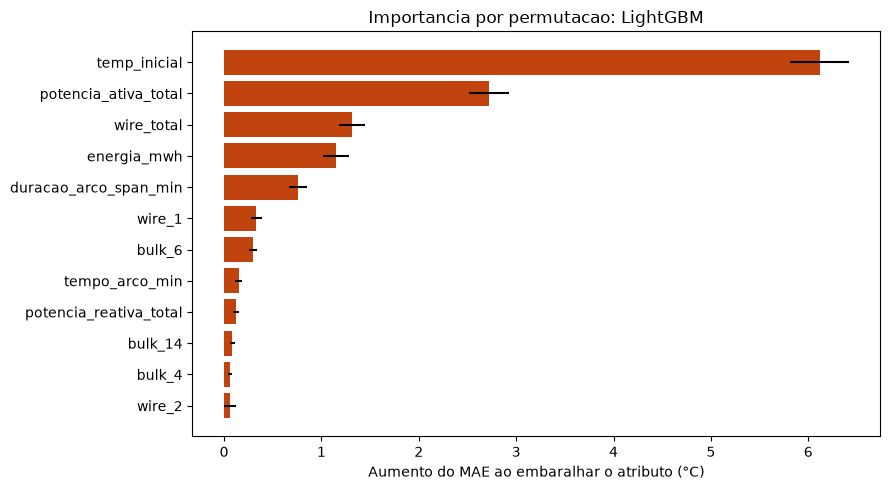

In [34]:
top = ranking.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top['atributo'], top['importancia'], xerr=top['desvio'], color='#c1440e')
ax.set_xlabel('Aumento do MAE ao embaralhar o atributo (°C)')
ax.set_title(f'Importancia por permutacao: {nome_campeao}')
plt.tight_layout(); plt.show()

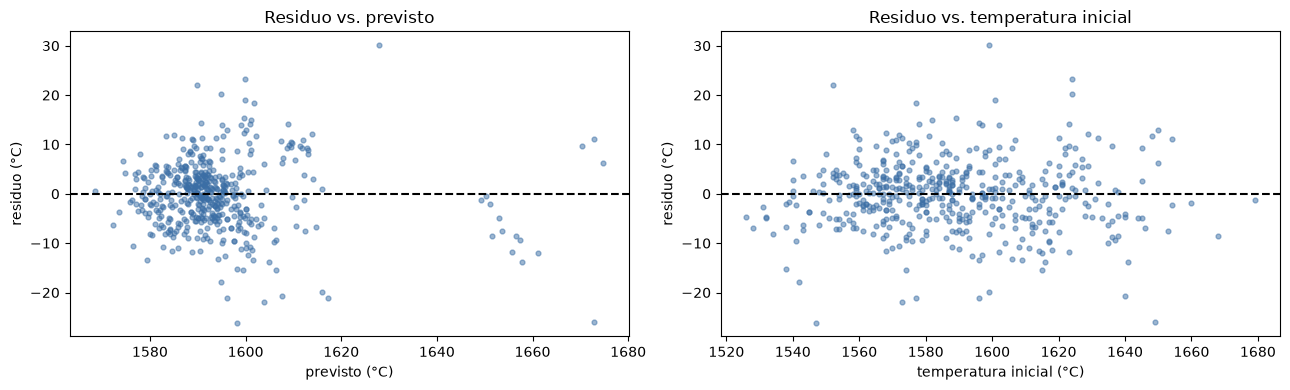

residuo: media -0.25 °C, desvio 6.98 °C
|residuo| <= 6.8 °C em 72.1% dos lotes de teste


In [35]:
residuo = y_teste - pred_cal   # previsao ja corrigida pelo vies da secao 3.7
pred = pred_cal

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].scatter(pred, residuo, s=12, alpha=.5, color='#3b6ea5')
ax[0].axhline(0, color='black', ls='--')
ax[0].set_xlabel('previsto (°C)'); ax[0].set_ylabel('residuo (°C)')
ax[0].set_title('Residuo vs. previsto')

ax[1].scatter(X_teste['temp_inicial'], residuo, s=12, alpha=.5, color='#3b6ea5')
ax[1].axhline(0, color='black', ls='--')
ax[1].set_xlabel('temperatura inicial (°C)'); ax[1].set_ylabel('residuo (°C)')
ax[1].set_title('Residuo vs. temperatura inicial')
plt.tight_layout(); plt.show()

print(f'residuo: media {residuo.mean():.2f} °C, desvio {residuo.std():.2f} °C')
print(f'|residuo| <= {META} °C em {100 * (residuo.abs() <= META).mean():.1f}% dos lotes de teste')

## 3.9 Escolha do modelo final

O modelo de menor MAE não é automaticamente o modelo a recomendar. Defini o critério na seção 3 do
plano: quando a diferença de erro entre dois candidatos é pequena, e ali citei 0,3 °C como
referência, a estabilidade e a explicabilidade devem pesar mais que o décimo de grau.

A diferença de MAE entre LightGBM e CatBoost é de apenas 0,125 °C, menos da metade desse limiar,
então o critério se aplica e a escolha não pode sair só do erro. O primeiro indício apontava para o
CatBoost: o gap entre treino e teste é de 1,57 °C no LightGBM contra 0,66 °C nele, o que sugeriria
menos sobreajuste.

Esse indício não se sustentou. A comparação completa abaixo, com calibração aplicada aos dois,
mostra o LightGBM à frente em todas as métricas medidas no teste, que são MAE, viés residual,
dispersão do resíduo e fração de lotes dentro da tolerância. A vantagem é pequena, mas é consistente
em vez de alternada.

O erro de leitura vale registrar, porque é sutil. Um gap grande acompanhado de bom desempenho no
teste significa que o modelo usa sua capacidade e ainda generaliza. Gap só seria motivo de alarme
junto com teste ruim. E como o conjunto de teste já mede generalização diretamente, preferir o gap a
ele é trocar a medida pela sua proxy.

Decido pelo LightGBM calibrado. O CatBoost fica registrado como a alternativa que previ testar, com
o resultado real: quase empatou, regularizou mais e não superou. As análises abaixo comparam os dois
lado a lado em calibração, importância e resíduos.

In [36]:
def calibra_e_avalia(nome, modelo, X_tr, y_tr, X_te, y_te, corte=0.9):
    '''Estima o vies na cauda final do treino e aplica ao teste.

    O vies nunca e medido no teste: usar a resposta para corrigir a previsao seria vazamento.
    '''
    k = int(len(X_tr) * corte)
    m = clone(modelo)
    m.fit(X_tr.iloc[:k], y_tr.iloc[:k])
    vies = float((y_tr.iloc[k:] - m.predict(X_tr.iloc[k:])).mean())

    bruto = modelo.predict(X_te)
    calibrado = bruto + vies
    linhas = []
    for rotulo, pr in [('bruto', bruto), ('calibrado', calibrado)]:
        r = y_te - pr
        linhas.append({'modelo': nome, 'versao': rotulo,
                       'MAE': mean_absolute_error(y_te, pr),
                       'vies': r.mean(), 'desvio_residuo': r.std(),
                       'dentro_tolerancia_%': 100 * (r.abs() <= META).mean()})
    return vies, calibrado, pd.DataFrame(linhas)

vies_lgb, pred_lgb, cmp_lgb = calibra_e_avalia('LightGBM', busca_lgb.best_estimator_,
                                               X_treino, y_treino, X_teste, y_teste)
vies_cat, pred_cat, cmp_cat = calibra_e_avalia('CatBoost', busca_cat.best_estimator_,
                                               X_treino, y_treino, X_teste, y_teste)

print(f'vies estimado | LightGBM: {vies_lgb:+.3f} °C | CatBoost: {vies_cat:+.3f} °C')
print()
print(pd.concat([cmp_lgb, cmp_cat]).round(3).to_string(index=False))

vies estimado | LightGBM: -1.008 °C | CatBoost: -0.971 °C

  modelo    versao   MAE   vies  desvio_residuo  dentro_tolerancia_%
LightGBM     bruto 5.298 -1.259           6.983               70.492
LightGBM calibrado 5.220 -0.251           6.983               72.131
CatBoost     bruto 5.423 -1.405           7.008               69.057
CatBoost calibrado 5.347 -0.434           7.008               70.492


### Importância das variáveis nos dois modelos

Refaço a importância por permutação sobre o CatBoost e comparo com a do LightGBM. Se as duas
famílias apontarem os mesmos atributos, isso reforça que os modelos capturam relação física e não
particularidade do algoritmo.

In [37]:
imp_cat = permutation_importance(busca_cat.best_estimator_, X_teste, y_teste, n_repeats=15,
                                 random_state=RANDOM_STATE, scoring='neg_mean_absolute_error',
                                 n_jobs=1)
rank_cat = (pd.DataFrame({'atributo': X_teste.columns,
                          'importancia_catboost': imp_cat.importances_mean})
              .sort_values('importancia_catboost', ascending=False))

comparativo = (rank_cat.merge(
        ranking[['atributo', 'importancia']].rename(columns={'importancia': 'importancia_lightgbm'}),
        on='atributo')
    .head(12))
print(comparativo.round(4).to_string(index=False))

              atributo  importancia_catboost  importancia_lightgbm
          temp_inicial                5.9747                6.1158
  potencia_ativa_total                2.0191                2.7213
 duracao_arco_span_min                0.8250                0.7588
           energia_mwh                0.7960                1.1461
          n_wire_tipos                0.4634               -0.0085
                bulk_6                0.2820                0.2962
        tempo_arco_min                0.1980                0.1483
                wire_1                0.1757                0.3294
            wire_total                0.1106                1.3154
potencia_reativa_total                0.0854                0.1220
               bulk_14                0.0504                0.0858
                bulk_1                0.0390                0.0327


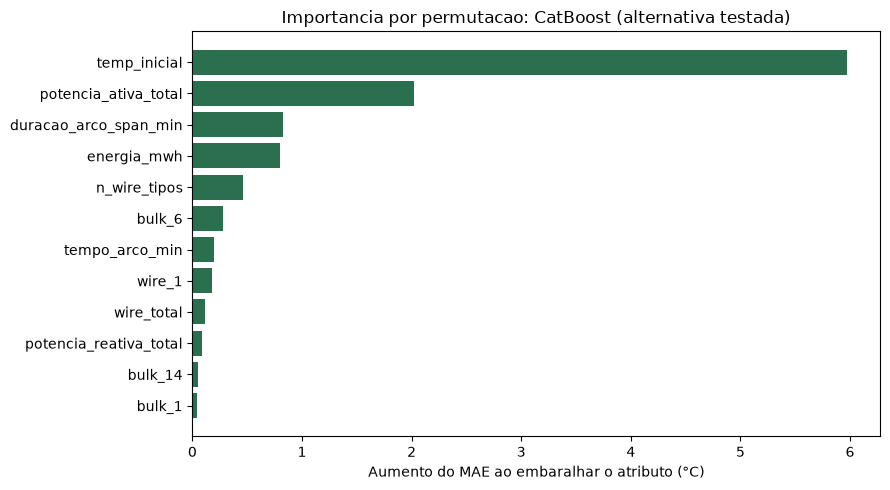

In [38]:
top = rank_cat.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top['atributo'], top['importancia_catboost'], color='#2a6f4e')
ax.set_xlabel('Aumento do MAE ao embaralhar o atributo (°C)')
ax.set_title('Importancia por permutacao: CatBoost (alternativa testada)')
plt.tight_layout(); plt.show()

### Resíduos e distribuição do erro

Os gráficos abaixo são do CatBoost calibrado, para fechar a comparação com os do LightGBM na seção
3.8. O que procuro é ausência de padrão. O segundo gráfico é o teste mais específico deste caso,
porque a temperatura inicial é de longe o atributo mais importante e qualquer estrutura ali
significaria sinal que o modelo deixou na mesa.

A tabela final quebra o erro absoluto em faixas. Ela responde a uma pergunta que o percentual único
não responde: entre os lotes fora da tolerância, quantos erram por pouco e quantos erram muito. É a
informação de que a operação precisa para saber quando não confiar na estimativa.

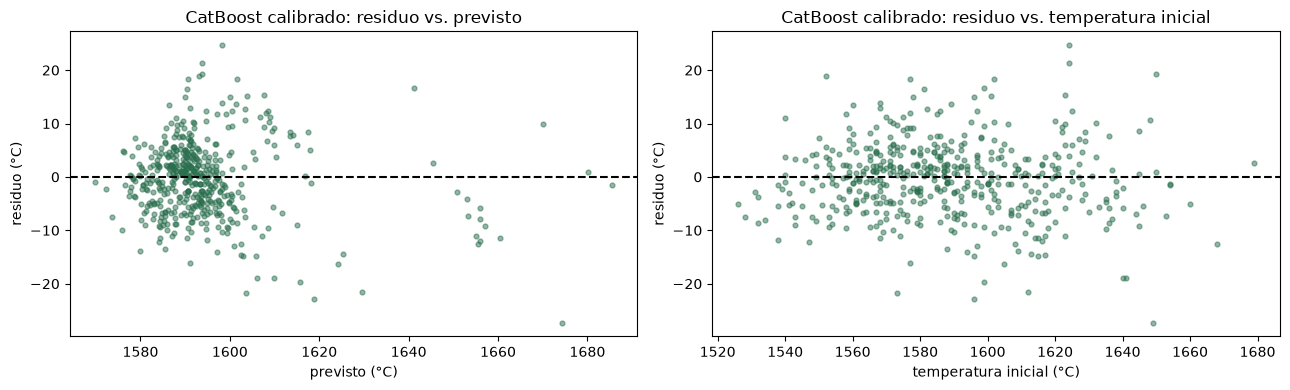

CatBoost calibrado | MAE 5.347 °C | vies -0.434 °C | desvio 7.008 °C
dentro de +-6.8 °C: 70.5% dos lotes

Distribuicao do erro absoluto:
temp_final
<=3         38.3
3 a 6,8     32.2
6,8 a 10    16.0
10 a 20     12.3
>20          1.2


In [39]:
res_cat = y_teste - pred_cat

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].scatter(pred_cat, res_cat, s=12, alpha=.5, color='#2a6f4e')
ax[0].axhline(0, color='black', ls='--')
ax[0].set_xlabel('previsto (°C)'); ax[0].set_ylabel('residuo (°C)')
ax[0].set_title('CatBoost calibrado: residuo vs. previsto')

ax[1].scatter(X_teste['temp_inicial'], res_cat, s=12, alpha=.5, color='#2a6f4e')
ax[1].axhline(0, color='black', ls='--')
ax[1].set_xlabel('temperatura inicial (°C)'); ax[1].set_ylabel('residuo (°C)')
ax[1].set_title('CatBoost calibrado: residuo vs. temperatura inicial')
plt.tight_layout(); plt.show()

print(f'CatBoost calibrado | MAE {mean_absolute_error(y_teste, pred_cat):.3f} °C | '
      f'vies {res_cat.mean():+.3f} °C | desvio {res_cat.std():.3f} °C')
print(f'dentro de +-{META} °C: {100 * (res_cat.abs() <= META).mean():.1f}% dos lotes')
print()
faixas = pd.cut(res_cat.abs(), [0, 3, 6.8, 10, 20, np.inf],
                labels=['<=3', '3 a 6,8', '6,8 a 10', '10 a 20', '>20'])
print('Distribuicao do erro absoluto:')
print((faixas.value_counts().sort_index() / len(res_cat) * 100).round(1).to_string())

---

# 4. Resumo dos resultados

## 4.1 O que o modelo entrega

O modelo recomendado é o LightGBM com calibração de viés, treinado sobre 1.950 corridas e avaliado
em 488 corridas posteriores no tempo, que ele nunca viu.

O número que interessa à operação é um só: quanto o modelo erra, em graus, ao dizer com que
temperatura o aço vai terminar. O quadro abaixo reúne isso junto com o que o piso e a meta pedem.

In [40]:
melhor_lgb = cmp_lgb[cmp_lgb['versao'] == 'calibrado'].iloc[0]
linha_lgb  = tabela.loc[tabela['modelo'] == 'LightGBM'].iloc[0]

print('MODELO RECOMENDADO: LightGBM com calibracao de vies')
print('=' * 62)
print(f'  treino ......................... {len(X_treino)} corridas')
print(f'  teste (posterior no tempo) ..... {len(X_teste)} corridas')
print()
print(f'  MAE no teste ................... {melhor_lgb["MAE"]:.2f} °C')
print(f'  meta do plano .................. {META} °C          -> '
      f'{"ATINGIDA" if melhor_lgb["MAE"] <= META else "NAO atingida"}')
print(f'  piso medido (modelo trivial) ... {PISO:.2f} °C')
print(f'  reducao do erro vs. o piso ..... {100 * (PISO - melhor_lgb["MAE"]) / PISO:.1f}%')
print()
print(f'  RMSE ........................... {linha_lgb["RMSE_teste"]:.2f} °C')
print(f'  R2 ............................. {linha_lgb["R2_teste"]:.3f}')
print(f'  vies residual .................. {melhor_lgb["vies"]:+.3f} °C')
print(f'  corridas dentro de +-{META} °C ... {melhor_lgb["dentro_tolerancia_%"]:.1f}%')

MODELO RECOMENDADO: LightGBM com calibracao de vies
  treino ......................... 1950 corridas
  teste (posterior no tempo) ..... 488 corridas

  MAE no teste ................... 5.22 °C
  meta do plano .................. 6.8 °C          -> ATINGIDA
  piso medido (modelo trivial) ... 10.42 °C
  reducao do erro vs. o piso ..... 49.9%

  RMSE ........................... 7.09 °C
  R2 ............................. 0.789
  vies residual .................. -0.251 °C
  corridas dentro de +-6.8 °C ... 72.1%


Em linguagem de operação: para cerca de sete em cada dez corridas, a previsão já cai dentro da
tolerância que o próprio KPI define. Isso é o que permite dispensar um ciclo de ajuste, que era o
objetivo declarado na Etapa 1.

Sobre o ganho energético, preciso ser específico quanto ao que os dados sustentam. Uma conversão
direta para reais não é defensável aqui, porque a unidade de `Active power` não vem documentada no
conjunto e não consegui calibrá-la, como detalho em 4.3. O que é defensável é a contagem. Cada
corrida passa hoje por uma mediana de quatro ciclos de aquecimento e quase cinco medições de
temperatura, e cada ciclo evitado é energia, desgaste de eletrodo e tempo de estação que deixam de
ser gastos. Transformar isso em reais exige uma informação que só a planta tem.

In [41]:
print(f'Ciclos de aquecimento por corrida: mediana {df["n_aquecimentos"].median():.0f}, '
      f'media {df["n_aquecimentos"].mean():.2f}')
print(f'Medicoes de temperatura por corrida: media {df["n_medicoes"].mean():.2f}')
print()
print(f'Taxa energetica medida na planta: {taxa:.5f} unidades de energia por °C de elevacao')
print('  (a unidade herda a de Active power, nao calibrada -- ver 4.3)')

Ciclos de aquecimento por corrida: mediana 4, media 4.58
Medicoes de temperatura por corrida: media 4.90

Taxa energetica medida na planta: 0.01213 unidades de energia por °C de elevacao
  (a unidade herda a de Active power, nao calibrada -- ver 4.3)


## 4.2 Onde o modelo erra

Dizer que 72% das corridas ficam dentro da tolerância deixa 28% de fora, e a operação precisa saber
se essas erram por pouco ou por muito. São coisas diferentes: errar 7 °C ainda orienta a decisão,
errar 25 °C atrapalha. Por isso quebro o erro em faixas em vez de reportar só o percentual.

In [42]:
erro_abs = (y_teste - pred_lgb).abs()
faixas_fim = pd.cut(erro_abs, [0, 3, META, 10, 20, np.inf],
                    labels=['ate 3 °C', f'3 a {META} °C', f'{META} a 10 °C', '10 a 20 °C', 'acima de 20 °C'])
dist = (faixas_fim.value_counts().sort_index() / len(erro_abs) * 100).round(1)
dist.index.name = 'faixa de erro'
print('Percentual das corridas de teste em cada faixa:')
print(dist.to_string())
print()
print(f'Erro mediano: {erro_abs.median():.2f} °C | percentil 90: {erro_abs.quantile(.90):.2f} °C '
      f'| maximo: {erro_abs.max():.2f} °C')

Percentual das corridas de teste em cada faixa:
faixa de erro
ate 3 °C          38.5
3 a 6.8 °C        33.6
6.8 a 10 °C       15.0
10 a 20 °C        10.9
acima de 20 °C     2.0

Erro mediano: 3.97 °C | percentil 90: 11.13 °C | maximo: 30.10 °C


A cauda é o que limita o uso do modelo. Um pedaço das corridas erra acima de 10 °C, e para essas a
estimativa não substitui a medição. A pergunta prática é se dá para reconhecer essas corridas pelo
tratamento que se pretende aplicar nelas. Se der, o modelo pode vir acompanhado de um aviso em vez
de ser usado às cegas.

In [43]:
grave = erro_abs > 10
perfil = pd.DataFrame({
    'erro_acima_de_10': X_teste[grave].mean(numeric_only=True),
    'demais_corridas':  X_teste[~grave].mean(numeric_only=True),
})
perfil['diferenca_%'] = 100 * (perfil['erro_acima_de_10'] - perfil['demais_corridas']) \
                        / perfil['demais_corridas'].replace(0, np.nan)

print(f'Corridas com erro acima de 10 °C: {grave.sum()} de {len(erro_abs)} '
      f'({100 * grave.mean():.1f}%)')
print()
print('Perfil medio dessas corridas contra as demais (atributos mais importantes):')
principais = ranking.head(8)['atributo'].tolist()
print(perfil.loc[[c for c in principais if c in perfil.index]].round(2).to_string())

Corridas com erro acima de 10 °C: 63 de 488 (12.9%)

Perfil medio dessas corridas contra as demais (atributos mais importantes):
                       erro_acima_de_10  demais_corridas  diferenca_%
temp_inicial                    1596.13          1586.29         0.62
potencia_ativa_total               3.70             2.98        24.34
wire_total                       102.51           112.91        -9.21
energia_mwh                        0.26             0.19        38.65
duracao_arco_span_min             36.83            28.90        27.48
wire_1                            82.20            92.19       -10.84
bulk_6                            22.68            23.96        -5.35
tempo_arco_min                    15.75            12.76        23.45


A resposta é sim, e ela é útil. As corridas em que o modelo erra muito não se distinguem pela
temperatura de entrada, que fica praticamente igual à das demais, com diferença de 0,6%. Elas se
distinguem pelo tratamento: consomem cerca de 39% mais energia, ficam 27% mais tempo em arco e
recebem 24% mais potência somada. São as corridas longas e pesadas.

Isso tem uma leitura física direta. Quanto mais longo o tratamento, mais tempo o banho troca calor
com o refratário, com o ambiente e com as adições, e mais o resultado depende de fatores que não
estão nos dados. O modelo é confiável no regime normal de operação e perde precisão exatamente onde
o processo se afasta dele.

E tem uma consequência prática, que é o motivo de eu ter feito esta análise. O que separa as
corridas ruins não é a temperatura de entrada, que ninguém escolhe, e sim o volume de tratamento,
que é decidido. Um plano que prevê muita energia e arco longo já indica, antes de a corrida começar,
que ali a estimativa merece confirmação por medição.

Registro o limite dessa leitura. As diferenças acima estão medidas sobre energia e tempo de arco
realizados, porque é o que os arquivos trazem. Transpor a regra para o plano supõe que o planejado
se aproxima do executado, o que é razoável para dimensionamento mas não consigo verificar com estes
dados. O modelo não precisa ser usado com o mesmo grau de confiança em todas as corridas, e essa é a
forma de decidir onde afrouxá-la.

## 4.3 O que o modelo não sabe

Este é o ponto que considero mais importante entregar junto com o resultado, porque um MAE dentro da
meta é fácil de ler como "problema resolvido" e não é o caso.

Começo pelo que é o inverso dos demais: em parte das corridas o modelo sabe demais. As variáveis de
processo agregam a corrida inteira e o alvo é a última medição de temperatura registrada, só que nem
sempre a última medição é o último evento. Contei 131 lotes em que um ciclo de arco termina depois
dela, 9 com adição de granel posterior e 2 com adição de arame, 135 corridas ao todo, ou 5,5% das
elegíveis. Nessas, a energia somada e o intervalo entre o primeiro e o último aquecimento carregam
informação que ainda não existia no instante do alvo. O MAE está provavelmente um pouco otimista por
causa disso, e não sei dizer o quanto sem reprocessar a base cortando as operações posteriores. O
caminho correto seria fixar o instante da previsão e agregar apenas o que ocorreu antes dele.

O mesmo desalinhamento aparece do outro lado. Em 98,7% dos lotes o primeiro aquecimento começa antes
da primeira medição de temperatura, e essa parcela permanece somada na energia total embora seu
efeito já esteja incorporado à temperatura inicial. A variável deixa de representar a energia
aplicada para levar o banho de uma temperatura à outra e passa a representar a energia da corrida
inteira. Isso não impede o modelo de prever, porque ele aprende a relação como ela se apresenta, mas
enfraquece a leitura física de que a energia da variável explica a elevação da temperatura.

O modelo não vê a composição química da corrida. Ligas diferentes têm calor específico e
comportamento térmico diferentes, e nada nos sete arquivos identifica qual liga está sendo
produzida. Parte do erro residual quase certamente vem daí, e nenhum ajuste de hiperparâmetro
alcança essa informação.

O modelo não vê o estado do refratário. Testei a única proxy disponível, o intervalo desde o lote
anterior, e ela não funcionou: a importância por permutação ficou praticamente em zero. Registro o
resultado como ele saiu. A hipótese era razoável e os dados não a sustentaram.

O modelo não vê a temperatura ambiente, o desgaste dos eletrodos, o histórico de manutenção nem a
condição da panela específica usada em cada corrida. Nenhuma dessas variáveis está no conjunto.

A unidade de `Active power` não é documentada. Testei calibrá-la pela física, comparando a energia
registrada com a elevação de temperatura obtida, e a massa implicada não bate com a capacidade de
100 t informada no enunciado sob nenhuma hipótese razoável de rendimento. Isso não invalida o
modelo, porque ele aprende a relação entre a grandeza registrada e a temperatura seja qual for a
escala dela, mas invalida qualquer conversão para MWh ou reais feita a partir daqui. Para fazer essa
conta é preciso perguntar à planta o que a coluna mede.

O período coberto é de três meses. Não encontrei deriva no alvo dentro dessa janela, mas três meses
não garantem estabilidade ao longo de um ano, e um modelo em produção precisaria ser reavaliado
periodicamente contra medições novas.

O conjunto perdeu 24% das corridas na limpeza, quase todas por terem uma única medição de
temperatura registrada. Se o protocolo de gravação da fábrica continuar como ficou a partir de
06/08/2019, dados novos chegam nesse mesmo formato e não servem nem para treinar nem para validar.
Restabelecer o registro de múltiplas medições é pré-requisito para manter o modelo vivo, e isso é
uma decisão da fábrica, não do modelo.

## 4.4 Desvios em relação ao plano da Etapa 1

Deixo esta consolidação para o fim de propósito. Cada desvio já apareceu na seção em que os dados o
provocaram, e reuni-los aqui, depois da evidência, é diferente de anunciá-los no começo como se eu
já soubesse o que ia encontrar.

In [44]:
desvios = pd.DataFrame([
    {'item': 'Piso do modelo trivial',
     'plano': '12,80 °C',
     'medido': f'{PISO:.2f} °C',
     'consequencia': 'ganho recalculado sobre o piso medido, nao sobre o prometido'},
    {'item': 'Tamanho do dataset',
     'plano': '2.475 lotes',
     'medido': f'{len(df)} lotes',
     'consequencia': 'cortes adicionais de duracao e de leituras impossiveis'},
    {'item': 'Leituras iniciais impossiveis',
     'plano': '1 outlier estatistico',
     'medido': '4 lotes, por prova energetica',
     'consequencia': 'criterio trocado por argumento interno aos dados'},
    {'item': 'Corte de 06/08/2019',
     'plano': 'filtro independente',
     'medido': 'redundante com o de 2 medicoes',
     'consequencia': 'remove poucos lotes sobreviventes, nao a janela toda'},
    {'item': 'Modelo linear',
     'plano': 'condicionado ao VIF',
     'medido': 'VIF > 10 em 4 atributos',
     'consequencia': 'Ridge treinado, conforme a condicao previa'},
    {'item': 'CatBoost',
     'plano': 'alternativa se LightGBM instavel',
     'medido': f'testado, MAE {cmp_cat[cmp_cat["versao"]=="calibrado"]["MAE"].iloc[0]:.2f} °C',
     'consequencia': 'nao superou o LightGBM; mantido como registro'},
    {'item': 'Proxy do refratario',
     'plano': 'hipotese a testar',
     'medido': f'importancia {ranking.set_index("atributo").loc["log_intervalo", "importancia"]:.3f} °C',
     'consequencia': 'hipotese nao sustentada; reportada como resultado'},
    {'item': 'Calibracao de vies',
     'plano': 'nao prevista',
     'medido': f'{vies_lgb:+.3f} °C estimados e descontados',
     'consequencia': f'MAE de {linha_lgb["MAE_teste"]:.2f} para {melhor_lgb["MAE"]:.2f} °C'},
])
print(desvios.to_string(index=False))

                         item                            plano                            medido                                                 consequencia
       Piso do modelo trivial                         12,80 °C                          10.42 °C ganho recalculado sobre o piso medido, nao sobre o prometido
           Tamanho do dataset                      2.475 lotes                        2438 lotes       cortes adicionais de duracao e de leituras impossiveis
Leituras iniciais impossiveis            1 outlier estatistico     4 lotes, por prova energetica             criterio trocado por argumento interno aos dados
          Corte de 06/08/2019              filtro independente    redundante com o de 2 medicoes         remove poucos lotes sobreviventes, nao a janela toda
                Modelo linear              condicionado ao VIF           VIF > 10 em 4 atributos                   Ridge treinado, conforme a condicao previa
                     CatBoost alternativa se LightGB

Nenhum desses desvios é falha de planejamento. Plano é hipótese sobre dados que ainda não foram
processados, e a Etapa 2 é justamente onde a hipótese encontra o dado. O que seria falha é ajustar o
resultado ao que foi prometido, e o caso do piso é o exemplo concreto. Manter os 12,8 °C do plano
teria inflado o ganho relatado de 49,9% para 59,2% sem que uma linha do modelo mudasse.

## 4.5 Conclusão

O modelo atinge a meta com folga. O erro cai de cerca de 10 °C do modelo trivial para pouco mais de
5 °C, uma redução próxima da metade, e sete em cada dez corridas ficam dentro da tolerância de
6,8 °C. O objetivo que defini na Etapa 1, que era dimensionar o aquecimento em vez de buscá-lo por
tentativa e erro, é alcançável com o que está aqui, desde que lido como comparação entre planos de
tratamento e não como previsão passiva.

O que eu levaria para a operação junto com o modelo são quatro coisas. A primeira é a cauda: em
torno de uma corrida em cada oito erra mais de 10 °C, e nessas a medição continua necessária. A
segunda é a unidade de `Active power`, sem a qual não há como transformar o ganho em reais. A
terceira é o formato de gravação a partir de 06/08/2019, que precisa voltar ao anterior para que o
modelo possa ser retreinado com dados novos. A quarta é o alinhamento temporal da seção 4.3: antes
de tratar os 5,22 °C como número definitivo, eu refaria o recorte agregando apenas operações
anteriores ao instante da previsão e mediria o pipeline em um bloco de tempo ainda não usado, já que
este teste também serviu para escolher entre as quatro famílias de modelo.